## India Air Pollution Analysis using Python

 The objective of this project is to analyze air pollution monitoring data across India, identify pollution patterns, compare states and cities, and derive meaningful insights through exploratory data analysis.

## 1: Data Understanding

1: Import Libraries

In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

2: Load Dataset

In [3]:
import pandas as pd

aqi = pd.read_csv("../data/India Air Pollution.csv")


3: Dataset Overview

In [4]:
aqi.head()


,country,state,city,station,last_update,latitude,longitude,pollutant_id,pollutant_min,pollutant_max,pollutant_avg
0,India,Bihar,Patna,"IGSC Planetarium Complex, Patna - BSPCB",02-07-2026 14:00:00,25.610369,85.132568,PM10,NaN,NaN,NaN
1,India,Bihar,Patna,"IGSC Planetarium Complex, Patna - BSPCB",02-07-2026 14:00:00,25.610369,85.132568,OZONE,59.0,60.0,60.0
2,India,Bihar,Purnia,"Mariam Nagar, Purnia - BSPCB",02-07-2026 14:00:00,25.366336,87.117468,NO2,4.0,6.0,6.0
3,India,Bihar,Rajgir,"Dangi Tola, Rajgir - BSPCB",02-07-2026 14:00:00,25.032800,85.419480,PM10,NaN,NaN,NaN
4,India,Bihar,Saharsa,"Police Line, Saharsa - BSPCB",02-07-2026 14:00:00,25.892357,86.590325,NH3,NaN,NaN,NaN


In [5]:
aqi.info()

<class 'pandas.DataFrame'>
RangeIndex: 3514 entries, 0 to 3513
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   country        3514 non-null   str    
 1   state          3514 non-null   str    
 2   city           3514 non-null   str    
 3   station        3514 non-null   str    
 4   last_update    3514 non-null   str    
 5   latitude       3514 non-null   float64
 6   longitude      3514 non-null   float64
 7   pollutant_id   3514 non-null   str    
 8   pollutant_min  3158 non-null   float64
 9   pollutant_max  3158 non-null   float64
 10  pollutant_avg  3158 non-null   float64
dtypes: float64(5), str(6)
memory usage: 559.9 KB


In [6]:
aqi.describe()

,latitude,longitude,pollutant_min,pollutant_max,pollutant_avg
count,3514.000000,3514.000000,3158.000000,3158.000000,3158.000000
mean,23.277241,78.534398,16.266941,46.640279,28.242242
std,5.155843,4.874285,16.268631,59.296273,27.824622
min,8.514909,70.776774,0.000000,0.000000,0.000000
25%,19.215784,75.387310,5.000000,13.000000,9.000000
50%,23.811588,77.272783,11.000000,29.000000,20.000000
75%,28.060249,80.612222,23.000000,57.000000,37.750000
max,34.066206,94.636574,134.000000,500.000000,299.000000


In [7]:
aqi.shape

(3514, 11)

Observation:

• The dataset contains air pollution records collected from monitoring stations across India.
• It includes location information such as state, city, station, latitude, and longitude.
• Pollution measurements include minimum, maximum, and average values for different pollutants.
• The dataset also contains the timestamp of the latest observation.


4: Data Cleaning

In [8]:
aqi.isnull().sum()

country            0
state              0
city               0
station            0
last_update        0
latitude           0
longitude          0
pollutant_id       0
pollutant_min    356
pollutant_max    356
pollutant_avg    356
dtype: int64

In [9]:
(aqi.isnull().sum()/len(aqi))*100

country           0.000000
state             0.000000
city              0.000000
station           0.000000
last_update       0.000000
latitude          0.000000
longitude         0.000000
pollutant_id      0.000000
pollutant_min    10.130905
pollutant_max    10.130905
pollutant_avg    10.130905
dtype: float64

In [10]:
aqi = aqi.dropna(subset=[
    "pollutant_min",
    "pollutant_max",
    "pollutant_avg"
])

In [11]:
aqi.isnull().sum()

country          0
state            0
city             0
station          0
last_update      0
latitude         0
longitude        0
pollutant_id     0
pollutant_min    0
pollutant_max    0
pollutant_avg    0
dtype: int64

In [12]:
aqi.duplicated().sum()

np.int64(0)

In [13]:
# checking data type 
aqi.dtypes

country              str
state                str
city                 str
station              str
last_update          str
latitude         float64
longitude        float64
pollutant_id         str
pollutant_min    float64
pollutant_max    float64
pollutant_avg    float64
dtype: object

5. Convert Date Column

In [14]:
aqi["last_update"] = pd.to_datetime(aqi["last_update"])

In [15]:
aqi.dtypes

country                     str
state                       str
city                        str
station                     str
last_update      datetime64[us]
latitude                float64
longitude               float64
pollutant_id                str
pollutant_min           float64
pollutant_max           float64
pollutant_avg           float64
dtype: object

6. Create New Time Features

In [16]:
aqi["year"] = aqi["last_update"].dt.year

In [17]:
aqi["month"] = aqi["last_update"].dt.month

In [18]:
aqi["day"] = aqi["last_update"].dt.day

In [19]:
aqi["hour"] = aqi["last_update"].dt.hour

In [20]:
aqi["day_name"] = aqi["last_update"].dt.day_name()

Observation:

• The dataset contained missing values in pollution measurement columns.

• Missing rows were removed to ensure accurate analysis.

• The date column was converted to datetime format for time-based analysis.

## 2: Exploratory Data Analysis (EDA)

1. Distribution of Air Pollutants Across Monitoring Stations

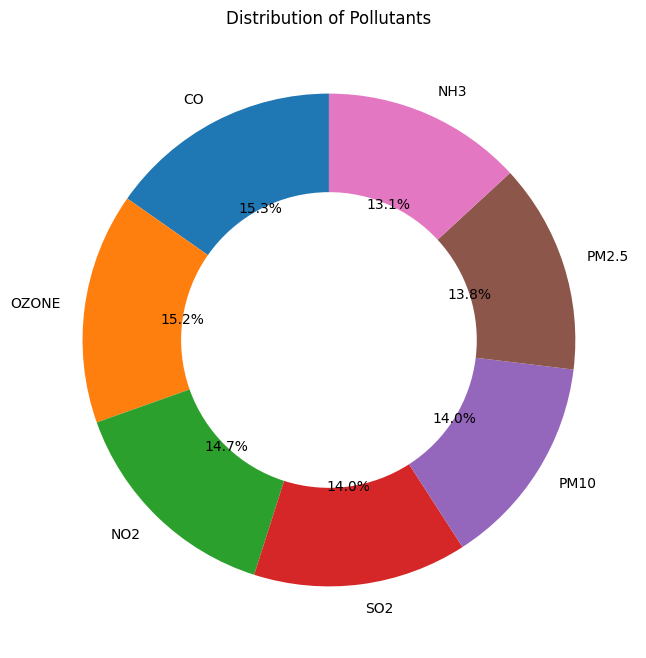

In [21]:
pollutant_counts = aqi["pollutant_id"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    pollutant_counts,
    labels=pollutant_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.4)
)

plt.title("Distribution of Pollutants")
plt.show()

Observation

Carbon Monoxide (CO) has the highest number of recorded observations in the dataset.

This indicates that CO is monitored more frequently than the other pollutants.

Pollutants with fewer records may have limited monitoring coverage across monitoring stations.

2. Which states contribute the most pollution monitoring records?

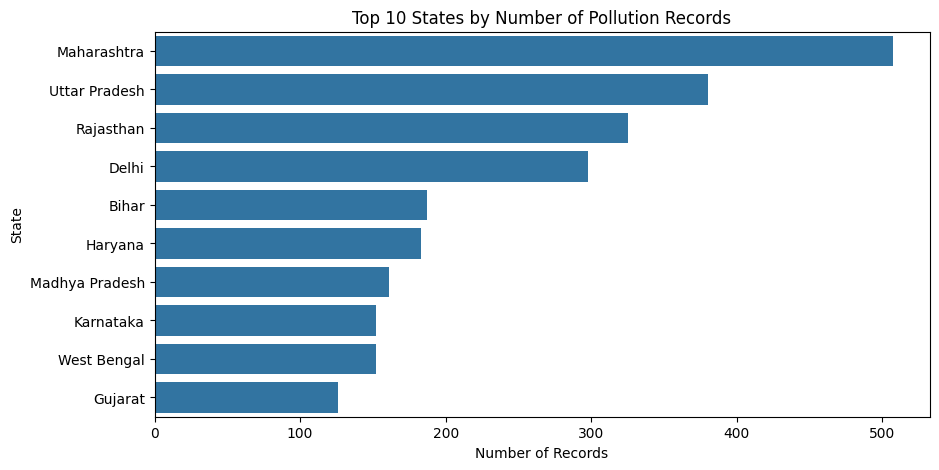

In [22]:
top_states = aqi["state"].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_states.values,
    y=top_states.index
)

plt.title("Top 10 States by Number of Pollution Records")
plt.xlabel("Number of Records")
plt.ylabel("State")

plt.show()

Observation

Maharashtra has the highest number of pollution monitoring records.

This suggests that Maharashtra has a wider monitoring network or more frequent data collection compared to other states.

The number of records reflects monitoring activity and should not be interpreted as the pollution level.

3. Which cities have the most pollution monitoring records?

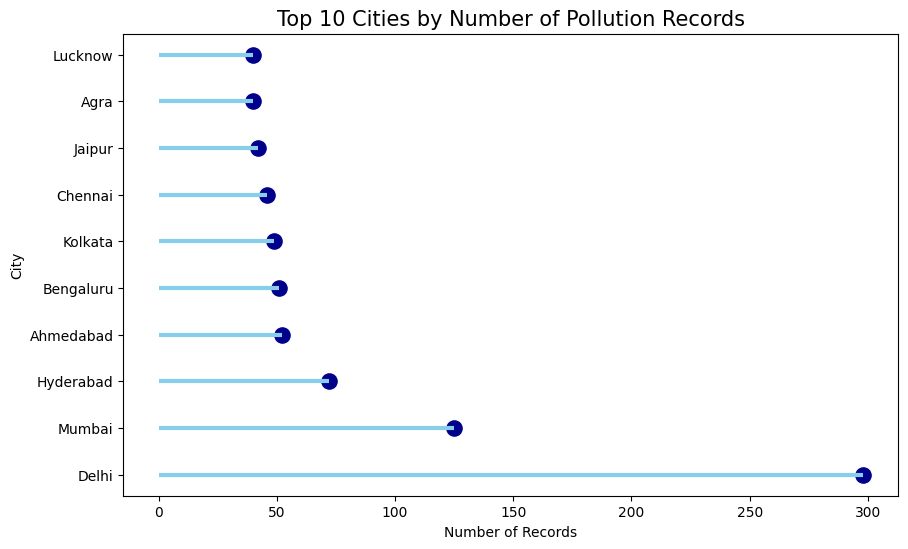

In [23]:
top_cities = aqi["city"].value_counts().head(10)

plt.figure(figsize=(10,6))

# Draw lines
plt.hlines(
    y=top_cities.index,
    xmin=0,
    xmax=top_cities.values,
    color="skyblue",
    linewidth=3
)

# Draw points
plt.scatter(
    top_cities.values,
    top_cities.index,
    color="darkblue",
    s=120
)

plt.title("Top 10 Cities by Number of Pollution Records", fontsize=15)
plt.xlabel("Number of Records")
plt.ylabel("City")

plt.show()

Obervation 

Delhi has the highest number of pollution records, followed by Mumbai.

These cities appear to have extensive air quality monitoring infrastructure.

A higher number of observations improves the reliability of pollution analysis for these locations.

4. Top 10 Indian States by Average Pollution Level

C:\Users\Admin\AppData\Local\Temp\ipykernel_10940\2090096440.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


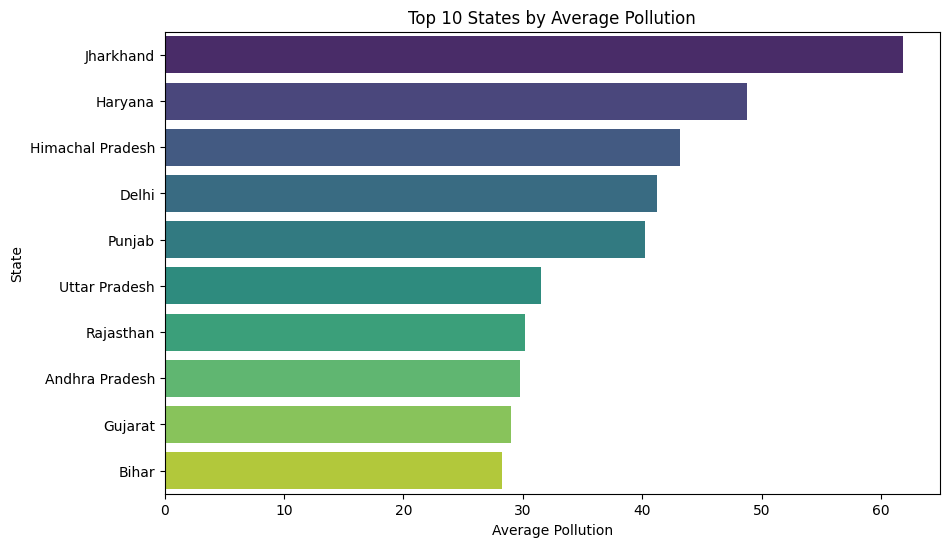

In [24]:
state_pollution = (
    aqi.groupby("state")["pollutant_avg"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=state_pollution.values,
    y=state_pollution.index,
    palette="viridis"
)

plt.title("Top 10 States by Average Pollution")

plt.xlabel("Average Pollution")

plt.ylabel("State")

plt.show()

Observation:

Jharkhand records the highest average pollution level among all states in the dataset.

This suggests that monitoring stations in Jharkhand experienced relatively higher pollutant concentrations.

Unlike the previous chart, this visualization represents pollution intensity rather than the number of monitoring records.

5: Top 10 Most Polluted Cities

C:\Users\Admin\AppData\Local\Temp\ipykernel_10940\202079695.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


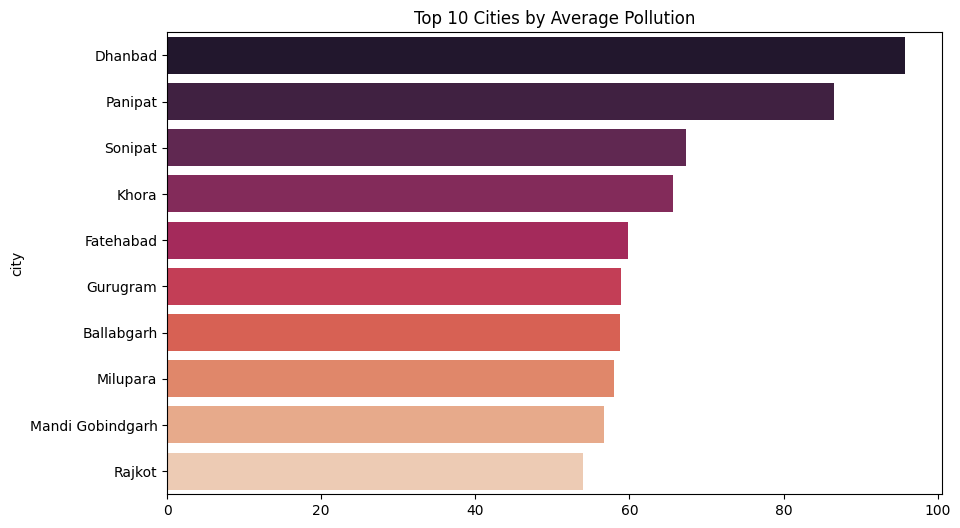

In [25]:
city_pollution = (
    aqi.groupby("city")["pollutant_avg"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=city_pollution.values,
    y=city_pollution.index,
    palette="rocket"
)

plt.title("Top 10 Cities by Average Pollution")

plt.show()

Observation:

Dhanbad has the highest average pollution level, followed by Panipat.

These cities recorded higher pollutant concentrations than other cities in the dataset.

The findings indicate that these locations may require stronger pollution control and environmental monitoring measures.

6: Average Pollution by Pollutant Type

C:\Users\Admin\AppData\Local\Temp\ipykernel_10940\70283283.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


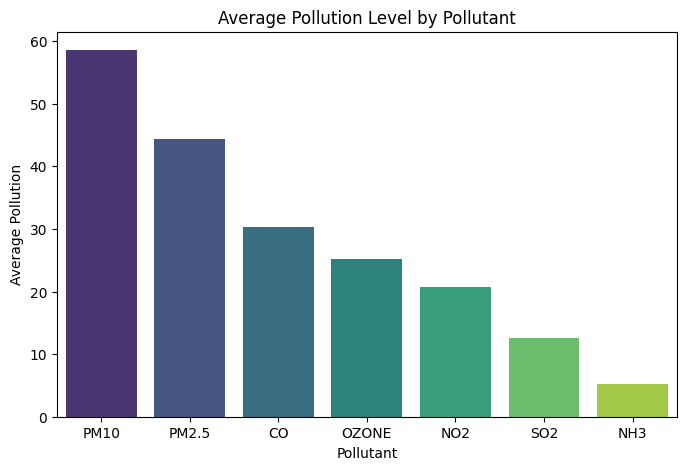

In [26]:
pollutant_avg = (
    aqi.groupby("pollutant_id")["pollutant_avg"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=pollutant_avg.index,
    y=pollutant_avg.values,
    palette="viridis"
)

plt.title("Average Pollution Level by Pollutant")

plt.xlabel("Pollutant")

plt.ylabel("Average Pollution")

plt.show()

Observation:

PM10 has the highest average concentration among all monitored pollutants.

NH3 (Ammonia) has the lowest average concentration in the dataset.

The higher concentration of particulate matter highlights it as one of the major contributors to air pollution.

Distribution of Average Pollutant Values

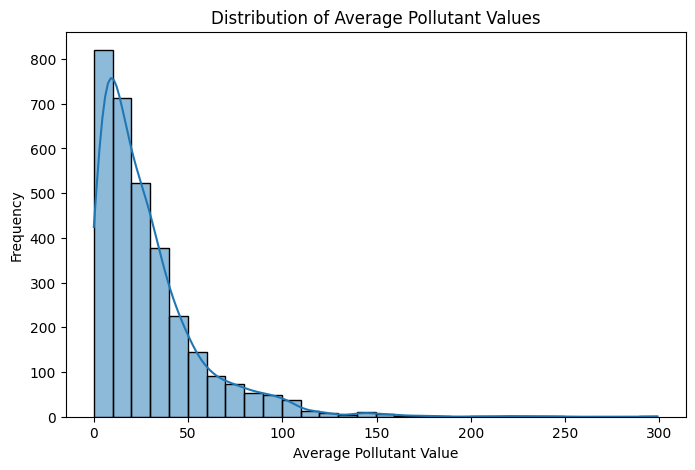

In [27]:
plt.figure(figsize=(8,5))

sns.histplot(aqi["pollutant_avg"], bins=30, kde=True)

plt.title("Distribution of Average Pollutant Values")
plt.xlabel("Average Pollutant Value")
plt.ylabel("Frequency")

plt.show()

Observation

Most pollution measurements are concentrated in the lower to moderate range.

A small number of observations have very high pollutant values, creating a right-skewed distribution.

These high-value observations may represent severe pollution episodes that warrant further investigation.

-------------------------------------------------------------------------------------------------------------------------------------------------


Key Findings

The dataset contains air pollution records collected from monitoring stations across India.

Carbon Monoxide (CO) is the most frequently monitored pollutant in the dataset.

Maharashtra has the highest number of pollution monitoring records, indicating extensive monitoring coverage.

Delhi records the highest number of city-level observations, followed by Mumbai.

Jharkhand has the highest average pollution level among all states.

Dhanbad and Panipat are the two cities with the highest average pollutant concentrations.

PM10 has the highest average pollutant concentration, while NH3 has the lowest.

Most pollutant measurements fall within lower concentration ranges, with a few extreme values indicating severe pollution events.